Confronto sul dataset iris
prova a variare il learning rate e come si comportano i due modelli

Allenamento in corso... attendere i risultati grafici.


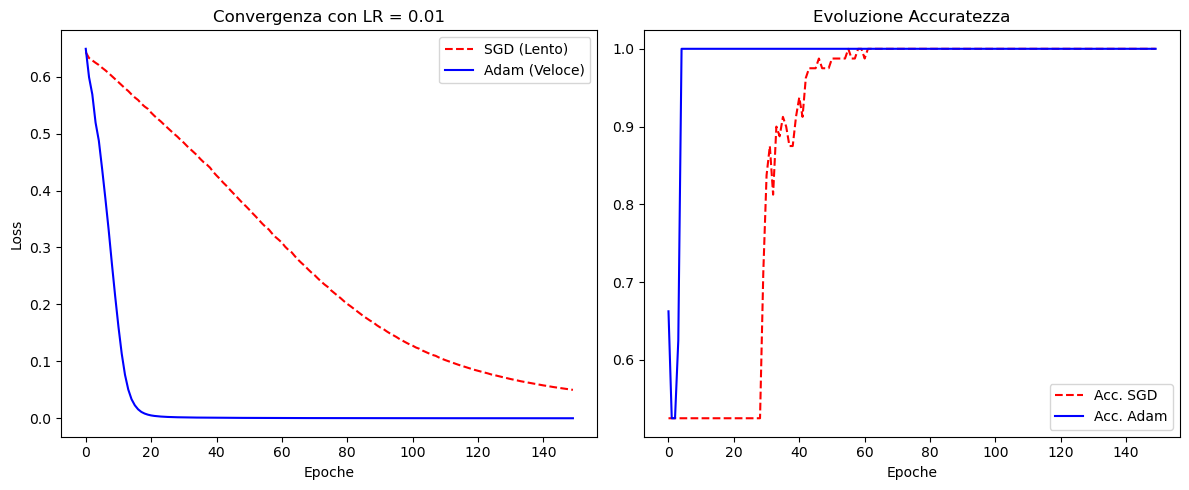

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam

# 1. Caricamento Dataset Iris (Semplificato a 2 classi per classificazione binaria)
data = load_iris()
X = data.data[data.target < 2]  # Prendiamo solo le prime due classi
y = data.target[data.target < 2]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def build_model():
    """Rete neurale identica alla lezione."""
    model = Sequential([
        Dense(10, activation='relu', input_shape=(4,)), # 4 feature in Iris
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model


# Qui vedremo la magia: Adam si adatterà, SGD farà fatica a muoversi
lr_critico = 0.01

# Modello SGD
model_sgd = build_model()
model_sgd.compile(optimizer=SGD(learning_rate=lr_critico), loss='binary_crossentropy', metrics=['accuracy'])

# Modello Adam
model_adam = build_model()
model_adam.compile(optimizer=Adam(learning_rate=lr_critico), loss='binary_crossentropy', metrics=['accuracy'])

# 3. Addestramento (Aumentiamo leggermente le epoche per vedere la divergenza)
epochs = 150
print("Allenamento in corso... attendere i risultati grafici.")

h_sgd = model_sgd.fit(X_train, y_train, epochs=epochs, verbose=0, validation_data=(X_test, y_test))
h_adam = model_adam.fit(X_train, y_train, epochs=epochs, verbose=0, validation_data=(X_test, y_test))

# 4. Visualizzazione
plt.figure(figsize=(12, 5))

# Grafico della Loss
plt.subplot(1, 2, 1)
plt.plot(h_sgd.history['loss'], label='SGD (Lento)', color='red', linestyle='--')
plt.plot(h_adam.history['loss'], label='Adam (Veloce)', color='blue')
plt.title(f'Convergenza con LR = {lr_critico}')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()

# Grafico Accuracy
plt.subplot(1, 2, 2)
plt.plot(h_sgd.history['accuracy'], label='Acc. SGD', color='red', linestyle='--')
plt.plot(h_adam.history['accuracy'], label='Acc. Adam', color='blue')
plt.title('Evoluzione Accuratezza')
plt.xlabel('Epoche')
plt.legend()

plt.tight_layout()
plt.show()